<a href="https://colab.research.google.com/github/alexshtf/alexshtf.github.io/blob/power_spectrum_moreau/power_spectrum_moreau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt

# Simplex coefficient projection

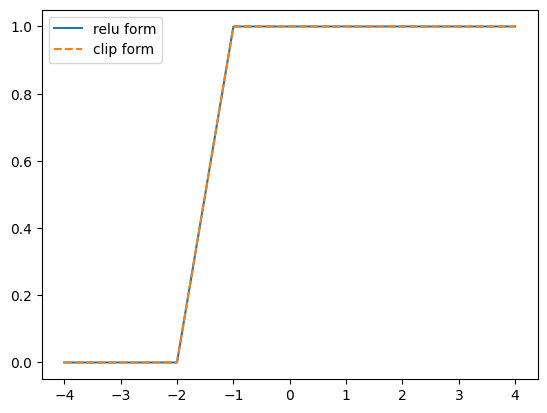

In [3]:
import numpy as np
import matplotlib.pyplot as plt

y = 2
nus = np.linspace(-4, 4, 1000)
plt.plot(nus, np.maximum(0, y + nus) - np.maximum(0, y-1 + nus), label='relu form')
plt.plot(nus, np.clip(y + nus, 0, 1), label='clip form', linestyle='--')
plt.legend()
plt.show()

In [4]:
def capped_simplex_lhs(ys, nus):
    return np.sum(
        np.clip(ys[np.newaxis, ...] + nus[..., np.newaxis], 0, 1),
        axis=-1
    )

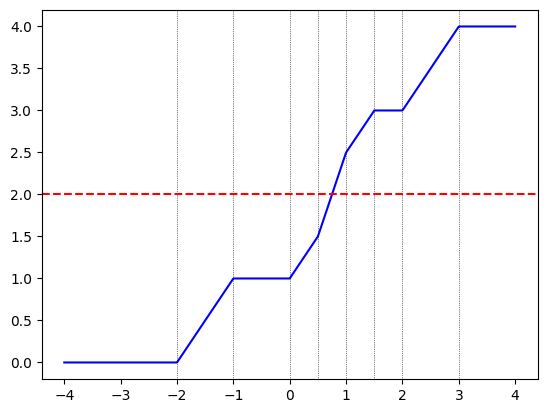

In [5]:
ys = np.array([-2, -0.5, 0, 2])
nus = np.linspace(-4, 4, 1000)
plt.plot(nus, capped_simplex_lhs(ys, nus), color='blue')
for y in ys:
    plt.axvline(-y, linestyle='dotted', linewidth=0.5, color='black')
    plt.axvline(1 - y, linestyle='dotted', linewidth=0.5, color='black')
plt.axhline(2, color='red', linestyle='--')
plt.show()

In [6]:
def capped_simplex_coefficients(y):
    """Return breaks, intercepts, and slopes for the piecewise-linear function

        f(x) = sum_j clip(y_j + x, 0, 1).

    On each interval between two breaks,

        f(x) = intercept + slope * x.
    """
    *B, N = y.shape

    # break points and slope contribution + bias contribution at each point
    breaks = np.concatenate([-y, 1 - y], axis=-1)
    slope_step = np.concatenate([np.ones_like(y), -np.ones_like(y)], axis=-1)
    intercept_step = np.concatenate([y, 1 - y], axis=-1)

    # sort all arrays by break points
    order = np.argsort(breaks, axis=-1)
    breaks = np.take_along_axis(breaks, order, axis=-1)
    slope_step = np.take_along_axis(slope_step, order, axis=-1)
    intercept_step = np.take_along_axis(intercept_step, order, axis=-1)

    # create coefficiens of all linear functions
    slopes = np.cumsum(slope_step, axis=-1)
    intercepts = np.cumsum(intercept_step, axis=-1)

    return breaks, slopes, intercepts

In [7]:
breaks, slopes, intercepts = capped_simplex_coefficients(ys)

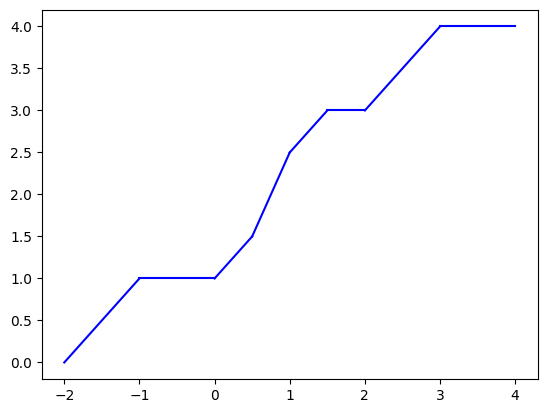

In [8]:
intervals = np.r_[breaks, 4]
for frm, to, slp, intr in zip(intervals[:-1], intervals[1:], slopes, intercepts):
    xs = np.linspace(frm, to, 100)
    plt.plot(xs, slp * xs + intr, color='blue')
plt.show()

In [9]:
r = 2

break_vals = breaks * slopes + intercepts
hit = np.argmax(break_vals >= r, axis=-1)  # index of first break valued below m
intr_idx = np.maximum(hit - 1, 0)          # index of interval = one before first hit
sol_x = (r - intercepts[intr_idx]) / slopes[intr_idx]

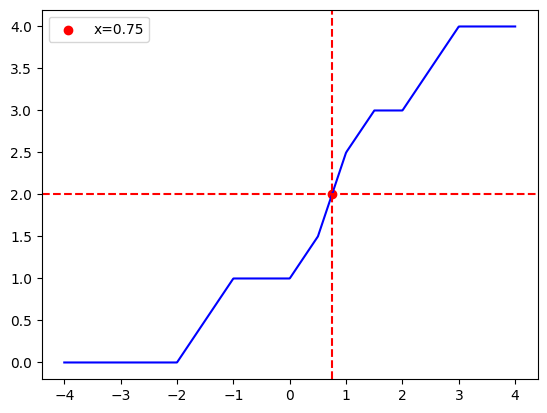

In [10]:
xs = np.linspace(-4, 4, 1000)
plt.plot(xs, capped_simplex_lhs(ys, xs), color='blue')
plt.axhline(r, color='red', linestyle='--')
plt.axvline(sol_x, color='red', linestyle='--')
plt.scatter(sol_x, r, color='red', label=f'x={sol_x:.2f}')
plt.legend()

In [11]:
def _gather_last(a: np.ndarray, index: np.ndarray) -> np.ndarray:
    return np.take_along_axis(a, index[..., None], axis=-1)[..., 0]

def solve_piecewise_linear(r, breaks, slopes, intercepts):
    value_at_breaks = intercepts + slopes * breaks

    hit = np.asarray(np.argmax(value_at_breaks >= r, axis=-1))
    intr_idx = np.maximum(hit - 1, 0)

    intercepts = _gather_last(intercepts, intr_idx)
    slopes = _gather_last(slopes, intr_idx)
    breaks = _gather_last(breaks, intr_idx)

    return np.divide(
        r - intercepts, slopes,
        out=np.array(breaks, copy=True),
        where=slopes != 0,
    )

In [12]:
solve_piecewise_linear(r, breaks, slopes, intercepts)

array(0.75)

In [13]:
def project_onto_capped_simplex(ys, r):
    breaks, slopes, intercepts = capped_simplex_coefficients(ys)
    x_sol = solve_piecewise_linear(r, breaks, slopes, intercepts)
    return np.clip(ys + x_sol[..., None], 0, 1)

In [14]:
prj = project_onto_capped_simplex(ys, 2)
prj, np.sum(prj)

(array([0.  , 0.25, 0.75, 1.  ]), np.float64(2.0))

In [15]:
sim_eigs = np.linspace(-2, 2, 15) ** 3
project_onto_capped_simplex(sim_eigs, 7)

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.21341108, 0.37667638, 0.4       , 0.42332362, 0.58658892,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [16]:
project_onto_capped_simplex(sim_eigs / 0.1, 7)

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.10009718, 0.33333333, 0.56656948, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

# Smooth KyFan

In [17]:
def kyfan(Ms, r):
    dim = Ms.shape[-1]
    eigs = sla.eigvalsh(Ms, subset_by_index=(dim - r, dim - 1))
    return np.sum(eigs, axis=-1)

In [18]:
np.random.seed(42)
A = np.random.randint(-1, 1, (5, 5))
B = np.random.randint(-1, 1, (5, 5))

In [19]:
xs = np.linspace(-2, 2, 200)
Ms = A[np.newaxis, ...] + xs[..., np.newaxis, np.newaxis] * B[np.newaxis, ...]

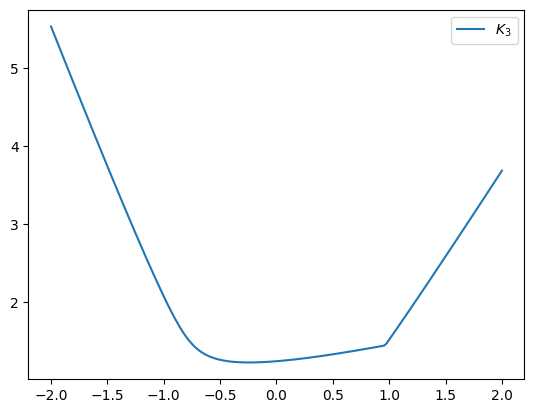

In [20]:
plt.plot(xs, kyfan(Ms, 3), label='$K_3$')
plt.legend()
plt.show()

In [21]:
def smooth_kyfan(Ms, r, alpha=1):
    dim = Ms.shape[-1]
    eigs = sla.eigvalsh(Ms)
    prj = project_onto_capped_simplex(eigs / alpha, r)
    return (
        np.sum(eigs * prj, axis=-1) - (alpha / 2) * np.sum(np.square(prj), axis=-1)
    )

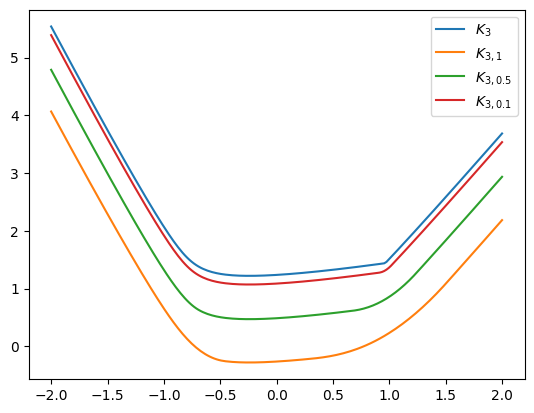

In [22]:
plt.plot(xs, kyfan(Ms, 3), label='$K_3$')
plt.plot(xs, smooth_kyfan(Ms, 3, alpha=1), label='$K_{3,1}$')
plt.plot(xs, smooth_kyfan(Ms, 3, alpha=0.5), label='$K_{3,0.5}$')
plt.plot(xs, smooth_kyfan(Ms, 3, alpha=0.1), label='$K_{3,0.1}$')
plt.legend()
plt.show()

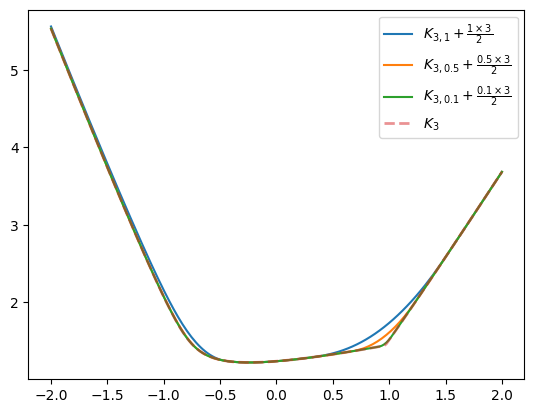

In [23]:
r = 3
plt.plot(
  xs, smooth_kyfan(Ms, r, alpha=1) + 1 * r / 2,
  label='$K_{3,1} + \\frac{1 \\times 3}{2}$'
)
plt.plot(
  xs, smooth_kyfan(Ms, r, alpha=0.5) + 0.5 * r / 2,
  label='$K_{3,0.5} + \\frac{0.5 \\times 3}{2}$'
)
plt.plot(
  xs, smooth_kyfan(Ms, r, alpha=0.1) + 0.1 * r / 2,
  label='$K_{3,0.1} + \\frac{0.1 \\times 3}{2}$'
)
plt.plot(xs, kyfan(Ms, 3), label='$K_3$', linewidth=2, alpha=0.5, linestyle='--')
plt.legend()
plt.show()

# Smooth $k$-th eigenvalue

In [24]:
def kth_eigval_smooth(Ms, k, alpha):
    n = Ms.shape[-1]
    r = n - k
    smooth_kyfan_r_neg = smooth_kyfan(Ms, r, alpha)
    smooth_kyfan_rm1_neg = smooth_kyfan(Ms, r - 1, alpha)
    return (smooth_kyfan_r_neg - smooth_kyfan_rm1_neg + alpha / 2)

In [25]:
def kth_eigval(Ms, k):
    return sla.eigvalsh(Ms, subset_by_index=(k, k))

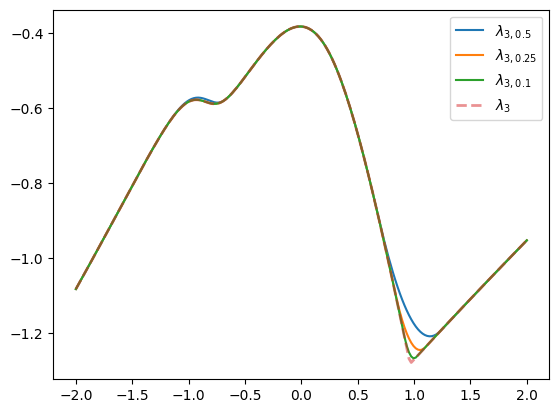

In [26]:
plt.plot(xs, kth_eigval_smooth(Ms, 2, alpha=0.5), label='$\\lambda_{3,0.5}$')
plt.plot(xs, kth_eigval_smooth(Ms, 2, alpha=0.25), label='$\\lambda_{3,0.25}$')
plt.plot(xs, kth_eigval_smooth(Ms, 2, alpha=0.1), label='$\\lambda_{3,0.1}$')
plt.plot(xs, kth_eigval(Ms, 2), label='$\\lambda_3$', linewidth=2, alpha=0.5, linestyle='--')
plt.legend()
plt.show()

# PyTorch autograd function

In [27]:
alpha = 0.5
r = 3

kink_mask = (0.7 <= xs) & (xs <= 1.2)
eigs = sla.eigvalsh(Ms[kink_mask])
prj_rp1 = project_onto_capped_simplex(eigs / alpha, r)
prj_r = project_onto_capped_simplex(eigs / alpha, r - 1)
ws = prj_rp1 - prj_r

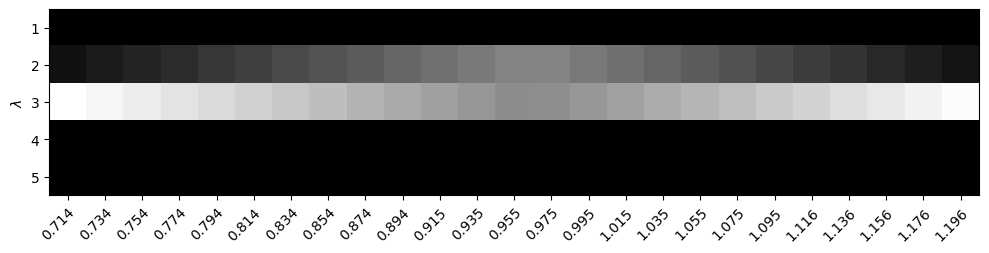

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(ws.T, cmap='gray')
ax.set_xticks(
    range(sum(kink_mask)),
    labels=[f'{x:.3f}' for x in xs[kink_mask]],
    rotation=45, ha="right", rotation_mode="anchor"
)
ax.set_ylabel('$\\lambda$')
ax.set_yticks(range(Ms.shape[-1]), labels=range(1, 1 + Ms.shape[-1]))
plt.show()

## Torch version of capped simplex coefficients

In [29]:
import torch

torch.set_printoptions(profile='short')
torch.set_num_threads(10)

print(torch.__version__)

2.11.0+cpu


In [30]:
def torch_capped_simplex_coefficients(y: torch.Tensor):
    """Return breaks, intercepts, and slopes for the piecewise-linear function

        f(x) = sum_j clip(y_j - x, 0, 1).

    On each interval between two breaks,

        f(x) = intercept + slope * x.
    """
    *B, N = y.shape

    # break points and slope contribution + bias contribution at each point
    breaks = torch.cat([y - 1, y], dim=-1)
    slope_step = torch.cat([-torch.ones_like(y), torch.ones_like(y)], dim=-1)
    bias_step = torch.cat([y - 1, -y], dim=-1)

    # sort all arrays by break points
    order = torch.argsort(breaks, dim=-1)
    breaks = torch.take_along_dim(breaks, order, dim=-1)
    slope_step = torch.take_along_dim(slope_step, order, dim=-1)
    bias_step = torch.take_along_dim(bias_step, order, dim=-1)

    # create coefficients of all linear functions
    slopes = torch.cumsum(slope_step, dim=-1)
    intercepts = N + torch.cumsum(bias_step, dim=-1)

    return breaks, slopes, intercepts

In [31]:
capped_simplex_coefficients(ys)

(array([-2. , -1. , -0. ,  0.5,  1. ,  1.5,  2. ,  3. ]),
 array([1., 0., 1., 2., 1., 0., 1., 0.]),
 array([2. , 1. , 1. , 0.5, 1.5, 3. , 1. , 4. ]))

In [32]:
torch_capped_simplex_coefficients(torch.as_tensor(ys).float())

(tensor([-3.00, -2.00, -1.50, -1.00, -0.50,  0.00,  1.00,  2.00]),
 tensor([-1.,  0., -1., -2., -1.,  0., -1.,  0.]),
 tensor([1.00, 3.00, 1.50, 0.50, 1.00, 1.00, 2.00, 0.00]))

### Torch version of capped simplex projection

In [33]:
def _torch_gather_last(a: torch.Tensor, index: torch.Tensor) -> torch.Tensor:
    return torch.take_along_dim(a, index[..., None], dim=-1)[..., 0]

def torch_solve_piecewise_linear(m, breaks, slopes, intercepts):
    value_at_breaks = intercepts + slopes * breaks

    hit_mask = value_at_breaks <= m
    hit = torch.argmax(hit_mask.to(torch.int8), dim=-1)
    seg_idx = torch.maximum(hit - 1, torch.zeros_like(hit))

    intercepts = _torch_gather_last(intercepts, seg_idx)
    slopes = _torch_gather_last(slopes, seg_idx)
    breaks = _torch_gather_last(breaks, seg_idx)

    nnz_slopes = slopes != 0
    out = breaks.detach().clone()
    out[nnz_slopes] = (m - intercepts[nnz_slopes]) / slopes[nnz_slopes]
    return out

In [34]:
def torch_project_onto_capped_simplex(ys, m):
    breaks, slopes, intercepts = torch_capped_simplex_coefficients(ys)
    x_sol = torch_solve_piecewise_linear(m, breaks, slopes, intercepts)
    return torch.clip(ys - x_sol[..., None], 0, 1)

In [35]:
ys_torch = torch.as_tensor(ys).float()
print('NumPy: ', project_onto_capped_simplex(ys, 2))
print('Torch: ', torch_project_onto_capped_simplex(ys_torch, 2))

NumPy:  [0.   0.25 0.75 1.  ]
Torch:  tensor([0.00, 0.25, 0.75, 1.00])


## Autograd function

In [36]:
class KthEigvalhSmooth(torch.autograd.Function):
    @staticmethod
    def forward(ctx, Ms, k, alpha):
        need_grad = ctx.needs_input_grad[0]

        # compute just eigenvalues or also eigenvectors
        if need_grad:
            eigs, eigvecs = torch.linalg.eigh(Ms)
        else:
            eigs = torch.linalg.eigvalsh(Ms)

        # project onto capped simplices (for top n-k and top n-k-1 eigenvalues)
        n = Ms.shape[-1]
        pr = torch_project_onto_capped_simplex(eigs / alpha, n - k)
        ps = torch_project_onto_capped_simplex(eigs / alpha, n - k - 1)
        weights = pr - ps

        # save eigenvectors and weights for backward
        if need_grad:
            ctx.save_for_backward(eigvecs, weights)

        # return the difference-of-smooth-KyFan approximation
        return (
            (weights * eigs).sum(dim=-1)
            - 0.5 * alpha * (pr.square().sum(dim=-1) - ps.square().sum(dim=-1))
            + 0.5 * alpha
        )

    @staticmethod
    def backward(ctx, grad_output):
        eigvecs, weights = ctx.saved_tensors

        G = (eigvecs * weights[..., None, :]) @ eigvecs.transpose(-2, -1)

        grad = torch.tril(2 * G)
        grad.diagonal(dim1=-2, dim2=-1).mul_(0.5)

        return grad_output[..., None, None] * grad, None, None

In [37]:
def torch_kth_eigvalh_smooth(Ms, k, tau):
    return KthEigvalhSmooth.apply(Ms, k, tau)

In [38]:
Ms = torch.randn(3, 5, 5)

In [39]:
X = torch.randn(3, 5, 5, dtype=torch.float64, requires_grad=True)

torch.autograd.gradcheck(
    lambda M: torch_kth_eigvalh_smooth(M, 2, 0.5),
    (X,),
)

True

# Train california housing

In [40]:
%pip install --q fitstream

In [41]:
import fitstream as fts

## Define the model

In [42]:
from torch import nn

In [43]:
class TrilEmbed(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

        # Get the coordinates of the lower triangle
        i, j = torch.tril_indices(dim, dim)

        # Build a lookup grid: which index of the input belongs at (row, col)?
        grid = torch.zeros(dim, dim, dtype=torch.long)
        grid[i, j] = torch.arange(len(i))

        # Symmetrize the map: copy lower indices to upper
        grid = torch.maximum(grid, grid.T)

        # Store the flattened map as a buffer
        self.map = nn.Buffer(grid.flatten())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Expands x of shape (..., K) to (..., d, d),  where K = d * (d + 1) // 2
        """
        return x[..., self.map].view(*x.shape[:-1], self.dim, self.dim)

In [44]:
TrilEmbed(4)(torch.randn(3, 4 * (4 + 1) // 2))

tensor([[[-0.70,  0.02, -1.30, -0.44],
         [ 0.02,  1.34, -1.52, -0.19],
         [-1.30, -1.52,  0.02, -0.35],
         [-0.44, -0.19, -0.35, -0.91]],

        [[ 0.79, -0.43,  0.53, -2.64],
         [-0.43,  0.23, -0.62, -0.71],
         [ 0.53, -0.62,  1.64,  0.42],
         [-2.64, -0.71,  0.42,  0.64]],

        [[ 1.43,  0.43, -0.56,  0.82],
         [ 0.43,  0.98, -1.37,  0.53],
         [-0.56, -1.37,  0.50, -0.42],
         [ 0.82,  0.53, -0.42, -0.33]]])

In [45]:
class SmoothKthEigvalhModel(nn.Module):
    def __init__(self, num_features, dim, k=None, alpha=0.1):
        super().__init__()
        self.lin = nn.Linear(num_features, dim * (dim + 1) // 2)
        self.tril_emb = TrilEmbed(dim)
        self.k = k or dim // 2
        self.alpha = alpha

    def forward(self, x):
        mat_flat = self.lin(x)
        mat = self.tril_emb(mat_flat)
        return torch_kth_eigvalh_smooth(mat, self.k, self.alpha)

## Prepartion - from previous post

In [46]:
import pandas as pd

train_df = pd.read_csv('sample_data/california_housing_train.csv')
test_df = pd.read_csv('sample_data/california_housing_test.csv')

In [47]:
TARGET = "median_house_value"
SKEWED_COLUMNS = ["total_rooms", "total_bedrooms", "population", "households"]

In [48]:
SKEWED_COLUMNS = ['total_rooms', 'total_bedrooms', 'population', 'households']
train_df[SKEWED_COLUMNS] = train_df[SKEWED_COLUMNS].apply(np.log)
test_df[SKEWED_COLUMNS] = test_df[SKEWED_COLUMNS].apply(np.log)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

target_idx = train_scaled.columns.get_loc(TARGET)
label_scale = float(scaler.scale_[target_idx])

In [50]:
from torch import as_tensor

def to_tensors(df):
    X = df.drop(columns=TARGET).to_numpy(dtype=np.float32)
    y = df[TARGET].to_numpy(dtype=np.float32)
    return torch.from_numpy(X), torch.from_numpy(y)

X_train, y_train = to_tensors(train_scaled)
X_test, y_test = to_tensors(test_scaled)

num_features = X_train.shape[1]

## Do the training

In [51]:
def scaled_rmse(y_true, y_pred):
    mse = nn.functional.mse_loss(y_pred, y_true)
    return torch.sqrt(mse) * label_scale

In [52]:
from torch.optim.lr_scheduler import OneCycleLR

def complete_training_stream(
        dim, n_epochs=75, alpha=0.1, warmup_fraction=0.1, lr=1e-2, batch_size=64,
    ):
    model = SmoothKthEigvalhModel(num_features=num_features, dim=dim, alpha=alpha)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    sched = OneCycleLR(optim, max_lr=lr, total_steps=n_epochs, pct_start=warmup_fraction, anneal_strategy='linear')

    epoch_events = fts.epoch_stream(
        (X_train, y_train), model, optim, nn.MSELoss(), batch_size=batch_size
    )
    return fts.pipe(
        epoch_events,
        fts.take(n_epochs),
        fts.augment(fts.validation_loss((X_test, y_test), scaled_rmse)),
        fts.augment(lambda event: {"lr": optim.param_groups[0]['lr']}),
        fts.tick(sched.step),
    )

In [66]:
for event in complete_training_stream(dim=5, n_epochs=11):
    print('step = ', event['step'],
          ', lr = ', event['lr'],
          ', val_loss = ', event['val_loss'])

step =  1 , lr =  0.0004 , val_loss =  90867.0078125
step =  2 , lr =  0.009090912727272728 , val_loss =  63868.4375
step =  3 , lr =  0.008080815757575757 , val_loss =  59900.1171875
step =  4 , lr =  0.007070718787878788 , val_loss =  59653.19921875
step =  5 , lr =  0.006060621818181819 , val_loss =  59391.703125
step =  6 , lr =  0.005050524848484848 , val_loss =  58910.65234375
step =  7 , lr =  0.0040404278787878785 , val_loss =  59091.203125
step =  8 , lr =  0.003030330909090909 , val_loss =  59128.265625
step =  9 , lr =  0.002020233939393939 , val_loss =  58527.10546875
step =  10 , lr =  0.0010101369696969686 , val_loss =  58274.375
step =  11 , lr =  3.999999999976245e-08 , val_loss =  58274.3671875


In [53]:
import matplotlib.pyplot as plt

def plot_loss(log, ax_loss=None, key='val_loss', loss_label='Eval. loss', title='Loss', color='blue'):
    ax_loss = plt.gca() if ax_loss is None else ax_loss
    losses = log[key]
    ax_loss.plot(
        log.step, losses, color=color,
        label=f'{loss_label} (best={losses.min():.2f}, avg={losses.mean():.2f})'
    )
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(title)
    ax_loss.grid()
    ax_loss.legend()


def plot_lr(log, lr_ax):
    lr_ax.plot(log.step, log.lr, label='Learning rate',
               color='gray', linestyle='dotted', linewidth=1)
    lr_ax.set_ylabel("Learning rate")


def plot_log(log, title=None):
    fig, ax_loss = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

    plot_loss(log, ax_loss, title='Error and learning rate')

    lr_ax = ax_loss.twinx()
    plot_lr(log, lr_ax)

    if title is not None:
        fig.suptitle(title)
    fig.show()

### Smoke test - 11 epochs

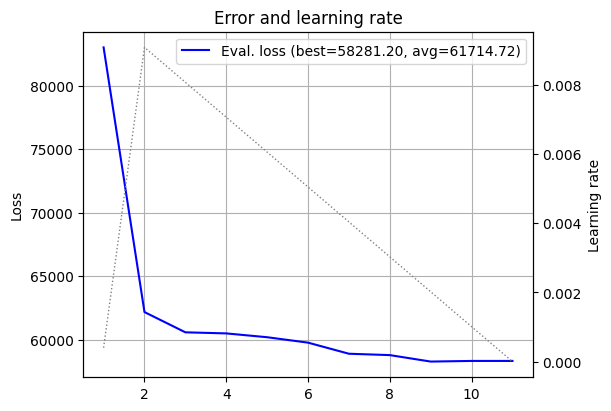

In [67]:
demo_log = fts.collect_pd(complete_training_stream(dim=5, n_epochs=11))
plot_log(demo_log)

### Real test

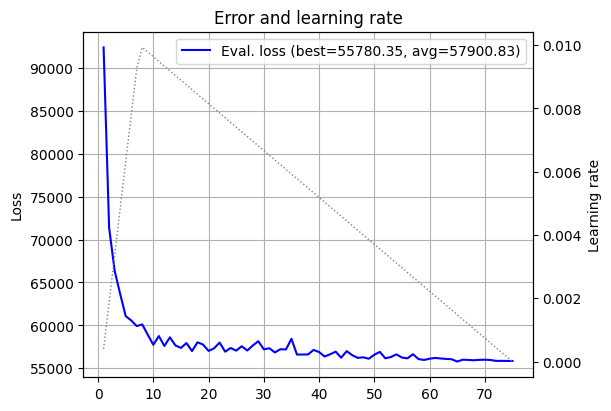

In [56]:
log_5 = fts.collect_pd(complete_training_stream(dim=5))
plot_log(log_5)

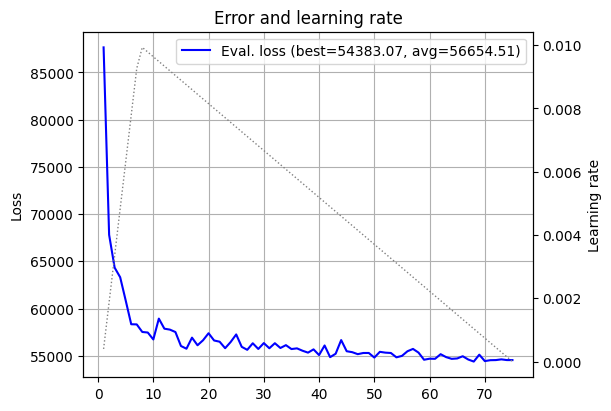

In [57]:
log_7 = fts.collect_pd(complete_training_stream(dim=7))
plot_log(log_7)

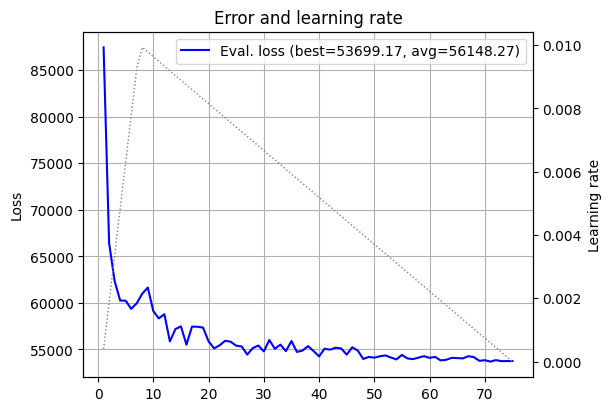

In [58]:
log_15 = fts.collect_pd(complete_training_stream(dim=15))
plot_log(log_15)

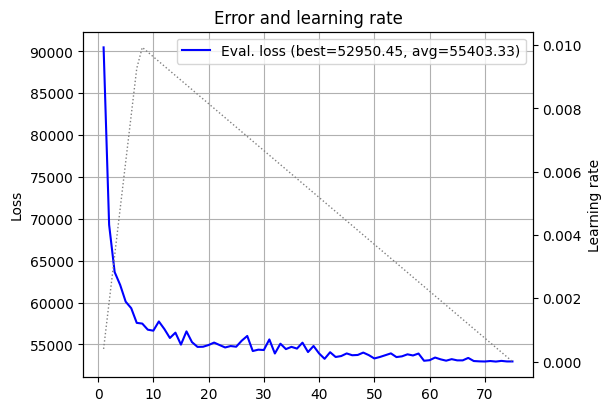

In [59]:
log_15_alpha_5 = fts.collect_pd(complete_training_stream(dim=15, alpha=5))
plot_log(log_15_alpha_5)

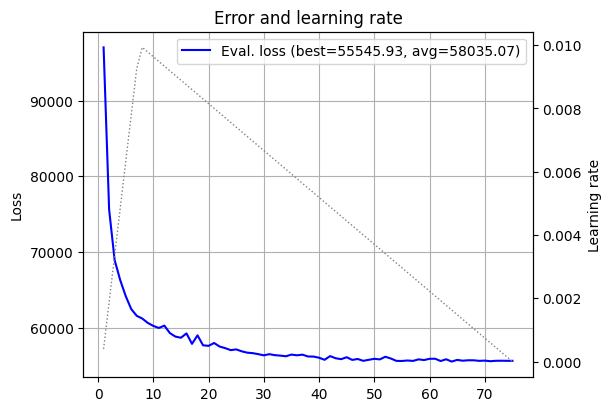

In [60]:
log_15_alpha_25 = fts.collect_pd(complete_training_stream(dim=15, alpha=25))
plot_log(log_15_alpha_25)

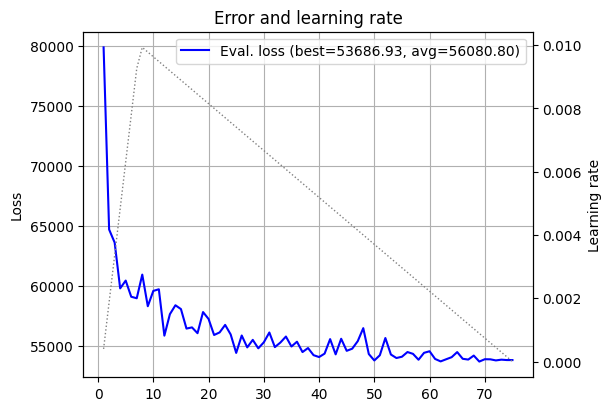

In [61]:
log_15_alpha_0_001 = fts.collect_pd(complete_training_stream(dim=15, alpha=0.001))
plot_log(log_15_alpha_0_001)

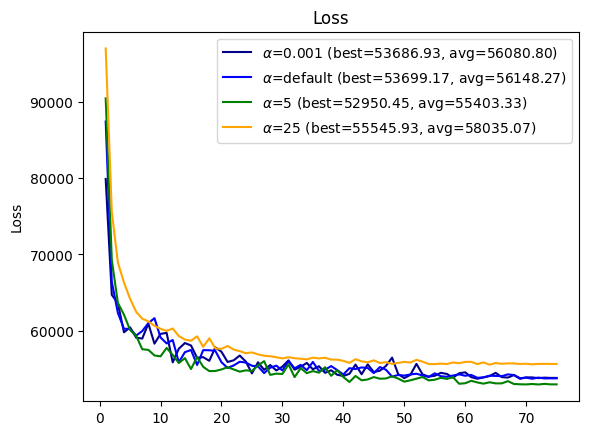

In [62]:
plot_loss(log_15_alpha_0_001, loss_label='$\\alpha$=0.001', color='darkblue')
plot_loss(log_15, loss_label='$\\alpha$=default', color='blue')
plot_loss(log_15_alpha_5, loss_label='$\\alpha$=5', color='green')
plot_loss(log_15_alpha_25, loss_label='$\\alpha$=25', color='orange')

In [68]:
from tqdm.auto import tqdm

alphas = [0.001, 0.1, 5]
n_repeats = 15

records = []
for alpha in alphas:
    for _ in tqdm(range(n_repeats), desc=f'alpha = {alpha}'):
        log = fts.collect_pd(complete_training_stream(dim=15, alpha=alpha))
        mean_loss = log['val_loss'].mean()
        records.append({'alpha': alpha, 'mean_loss': mean_loss})

alpha = 0.001:   0%|          | 0/15 [00:00<?, ?it/s]

alpha = 0.1:   0%|          | 0/15 [00:00<?, ?it/s]

alpha = 5:   0%|          | 0/15 [00:00<?, ?it/s]

In [71]:
df = pd.DataFrame.from_records(records)

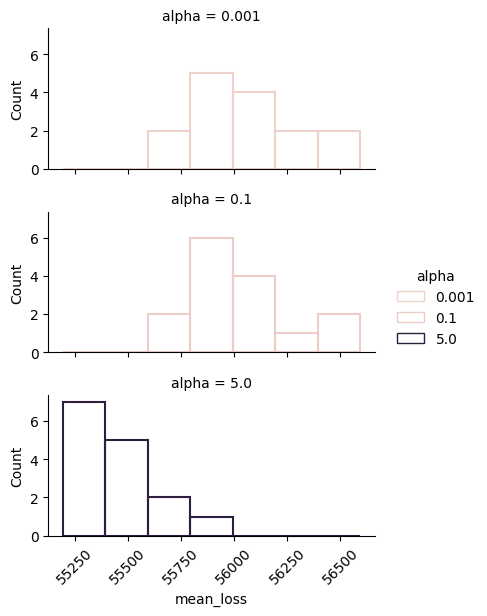

In [78]:
import seaborn as sns

g = sns.displot(df, x='mean_loss', row='alpha', fill=False, aspect=2, height=2, hue='alpha')
g.tick_params(axis='x', rotation=45)